In [1]:
import sys
sys.path.append("./HPO_B")  # Adjust the path to import from the parent directory
from hpob_handler import HPOBHandler
from methods.random_search import RandomSearch
import matplotlib.pyplot as plt
import pandas as pd

/home/amir/anaconda3/envs/ft-pfn/lib/python3.10/site-packages/xgboost/compat.py:106: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [2]:
def get_data_from_hpo_b_results(seeds, search_space_id, dataset_ids , method_name, init=5, time_limit=60):
    df = pd.read_json("./HPO_B/results/"+ method_name + ".json")
    df_id = df[int(search_space_id)]
    results = []
    for dataset_id in dataset_ids:
        df_id_data = df_id[int(dataset_id)]
        for seed in seeds:
            performances = df_id_data[seed]
            performances = [None]*init + performances + [max(performances)]*(time_limit - len(performances)) # Ensure performances is a list
            for iteration, performance in enumerate(performances):
                results.append({
                    "benchmark_name": "HPO-B",
                    "search_space_id": int(search_space_id),
                    "dataset_id": int(dataset_id),
                    "method": method_name + " (HPO-B)",
                    "seed": int(''.join(filter(str.isdigit, seed))),
                    "iteration": iteration, 
                    "performance": performance,
                    "configuration": None,
                    "duration": None
                })
    data = pd.DataFrame(results)
    return data

In [10]:
result_folder = "./results/"
benchmark_name = "HPO-B"
time_horizon = 100
initialization = 5
seeds = ["test" + str(i)  for i in range(5)]


method_names = ["Random-Search", "PFNs4BO-BNN", "PFNs4BO-HEBO" , "ourPFNs"] #"GP"]#, "PFNs4BO-HEBO", "ourPFNs"] , "ourPFNs",  "GP", "GP-UCB"

val_search_space_ids = [5527, 5891, 5906, 5971, 6767, 6766, 5860]
test_search_space_ids = [5859]# 5965, , 5889, 4796, 5859, 5970, 6794, 5636] #7607 7609

#method_names=[]
search_space_ids = test_search_space_ids# ["4796", "5527", "5891", "5965", "5971", "7607", "7609", "5889"]
#error ="5636" "5859", "5860", "5906", "5970", "6766" #gp , "6767", "6794"
resullt_methods = ["Random", "DGP", "GP", "DNGO"]#,"DGP"] #, "TAF", "TST", "RGPE"] #, "ourPFNs"] "Random", "DNGO","DGP", "TAF", "TST", "RGPE",


hpob_hdlr = HPOBHandler(root_dir="./HPO_B/hpob-data/", mode="v3-test")

df_list = []
for search_space_id in search_space_ids:
    search_space_id = str(search_space_id)
    dataset_ids = hpob_hdlr.get_datasets(search_space_id)
    for method_name in method_names:
        for dataset_id in dataset_ids:
            df = pd.read_csv(result_folder + benchmark_name + "_" + method_name + "_" + search_space_id +"_"+ dataset_id + ".csv")
            df_list.append(df.copy())
    for method_name in resullt_methods:
        df = get_data_from_hpo_b_results(seeds, search_space_id, dataset_ids,method_name, initialization, time_horizon)
        df_list.append(df.copy())
df_main = pd.concat(df_list, ignore_index=True)


Loading HPO-B handler
Loading data...


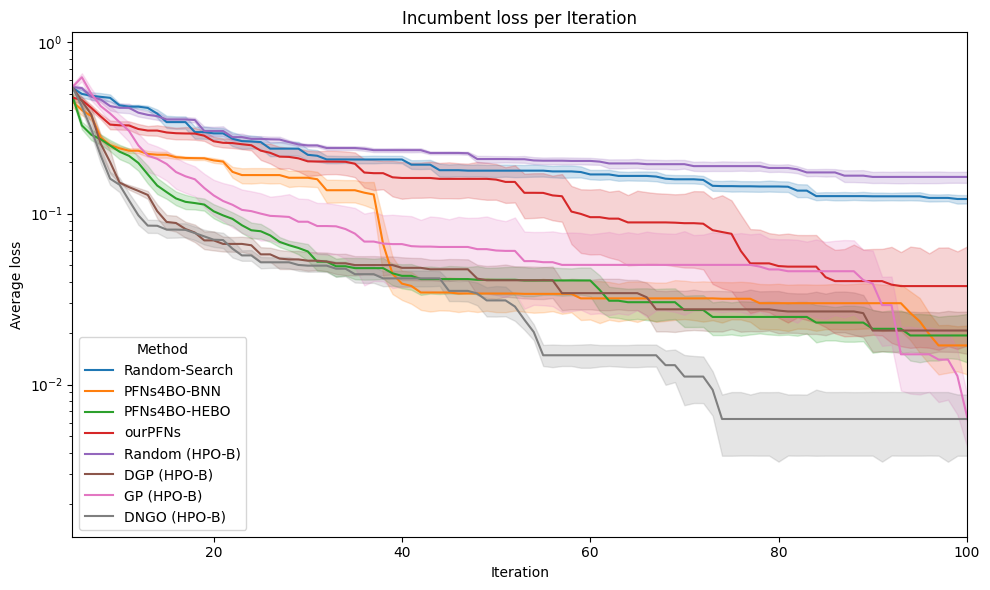

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

df = df_main[['search_space_id','dataset_id', 'method','iteration', 'seed', 'performance']].copy()
df[["search_space_id", "dataset_id"]] = df[["search_space_id", "dataset_id"]].apply(pd.to_numeric)

df['loss'] = 1 - df['performance'].round(8)
df['avg_loss'] = df.groupby(['method','iteration', 'seed'])['loss'].transform('mean')
df['rank'] = df.groupby(['search_space_id','dataset_id', 'seed', 'iteration'])['loss'].rank(ascending=True, method='average')
7609

# Plot
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x='iteration',
    y='avg_loss',
    hue='method',
    estimator='mean',
    errorbar=('ci', 95)
)
plt.title('Incumbent loss per Iteration')
plt.xlabel('Iteration')
plt.ylabel('Average loss')
plt.yscale('log')
plt.legend(title='Method')
plt.grid(False)
plt.xlim(initialization, time_horizon)
plt.tight_layout()
plt.show()

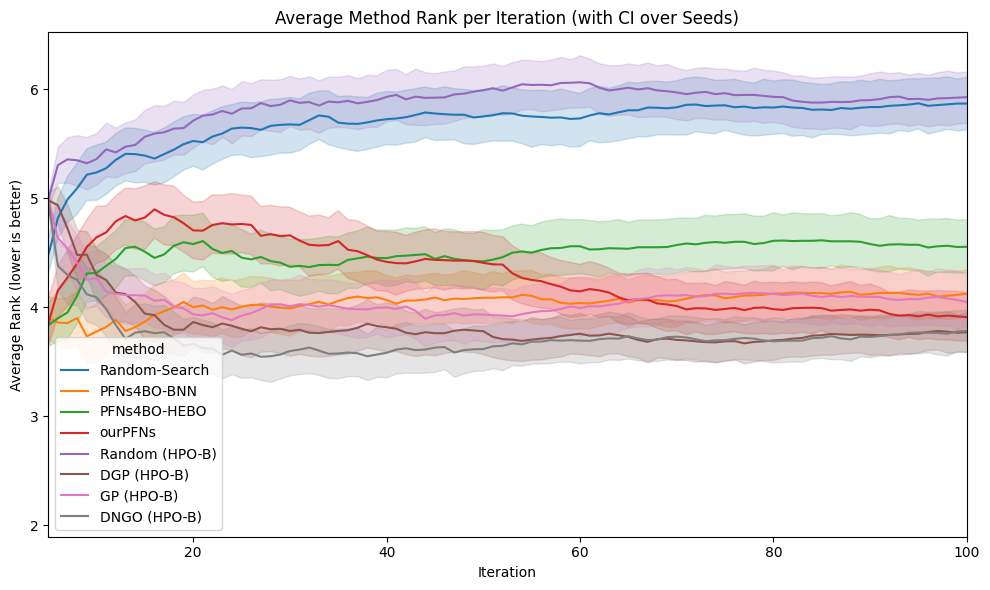

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 3: Plot with seaborn using confidence intervals or std
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x='iteration',
    y='rank',
    hue='method',
    estimator='mean',
    errorbar=('ci', 95)
)
plt.title('Average Method Rank per Iteration (with CI over Seeds)')
plt.xlabel('Iteration')
plt.ylabel('Average Rank (lower is better)')
plt.xlim(initialization, time_horizon)
plt.tight_layout()
plt.show()
